In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3.csv',sep=',',encoding='latin1')
raw_datam=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_columns.csv',sep=',',encoding='latin1')
raw_datam.rename(columns={'Unnamed: 1':'Message Type',
                                 'Unnamed: 2':'Protocole',
                                 'Unnamed: 3':'IMEI',
                                 'Unnamed: 4':'Serial',
                                 'Unnamed: 5':'Mileage',
                                 'Unnamed: 6':'Date',
                                 'Unnamed: 7':'Ignition',
                                 'Unnamed: 8':'Latitude',
                                 'Unnamed: 9':'Longitude',
                                 'Unnamed: 10':'Altitude',
                                 'Unnamed: 11':'External Power',
                                 'Unnamed: 12':'RPM',
                                 'Unnamed: 13':'Speed',
                                 'Unnamed: 14':'Satellite Number',
                                 'Unnamed: 15':'Azimuth',
                                 'Unnamed: 16':'Bettery level',
                                 },inplace=True)
raw_datam.info()
raw_datam.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_.csv')

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Message           58 non-null     str  
 1   Message Type      58 non-null     str  
 2   Protocole         58 non-null     str  
 3   IMEI              58 non-null     str  
 4   Serial            58 non-null     str  
 5   Mileage           58 non-null     str  
 6   Date              58 non-null     str  
 7   Ignition          58 non-null     str  
 8   Latitude          58 non-null     str  
 9   Longitude         58 non-null     str  
 10  Altitude          58 non-null     str  
 11  External Power    55 non-null     str  
 12  RPM               55 non-null     str  
 13  Speed             52 non-null     str  
 14  Satellite Number  52 non-null     str  
 15  Azimuth           52 non-null     str  
 16  Bettery level     52 non-null     str  
dtypes: str(17)
memory usage: 7.8 KB


In [3]:
raw_datam['Protocole'].value_counts()

Protocole
ProtocolHeadType:20    50
ProtocolHeadType:0      6
ProtocolHeadType:19     2
Name: count, dtype: int64

Odometer

In [4]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_.csv',sep=',')
unit['Odometer in meters']=0.0
unit.info()
unit_mileage=unit[unit['Date'].str.contains('2026-04-20T21')]
unit_mileage[['Mileage','Date','IMEI']]

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          58 non-null     int64  
 1   Message             58 non-null     str    
 2   Message Type        58 non-null     str    
 3   Protocole           58 non-null     str    
 4   IMEI                58 non-null     str    
 5   Serial              58 non-null     str    
 6   Mileage             58 non-null     str    
 7   Date                58 non-null     str    
 8   Ignition            58 non-null     str    
 9   Latitude            58 non-null     str    
 10  Longitude           58 non-null     str    
 11  Altitude            58 non-null     str    
 12  External Power      55 non-null     str    
 13  RPM                 55 non-null     str    
 14  Speed               52 non-null     str    
 15  Satellite Number    52 non-null     str    
 16  Azimuth             5

,Mileage,Date,IMEI
11,Mileage:44757,"Date:""2026-04-20T21:07:26Z""","Imei:""869487060215778"""
12,Mileage:44757,"Date:""2026-04-20T21:07:21Z""","Imei:""869487060215778"""
13,Mileage:44757,"Date:""2026-04-20T21:11:31Z""","Imei:""869487060215778"""
14,Mileage:44757,"Date:""2026-04-20T21:11:59Z""","Imei:""869487060215778"""
15,Mileage:44757,"Date:""2026-04-20T21:13:50Z""","Imei:""869487060215778"""
16,Mileage:44757,"Date:""2026-04-20T21:15:01Z""","Imei:""869487060215778"""
17,Mileage:44757,"Date:""2026-04-20T21:17:56Z""","Imei:""869487060215778"""
18,Mileage:44757,"Date:""2026-04-20T21:19:24Z""","Imei:""869487060215778"""
19,Mileage:44757,"Date:""2026-04-20T21:19:25Z""","Imei:""869487060215778"""
20,Mileage:44757,"Date:""2026-04-20T21:19:53Z""","Imei:""869487060215778"""


In [5]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_.csv',sep=',')
unit_mileage=unit[unit['Date'].str.contains('2026-04-20T:')]
unit_mileage[['Mileage','Date','IMEI']]

,Mileage,Date,IMEI


In [6]:
unit_odometer=unit[~unit['Protocole'].str.contains(':0')]
unit_odometer['Protocole'].value_counts()

Protocole
ProtocolHeadType:20    50
ProtocolHeadType:19     2
Name: count, dtype: int64

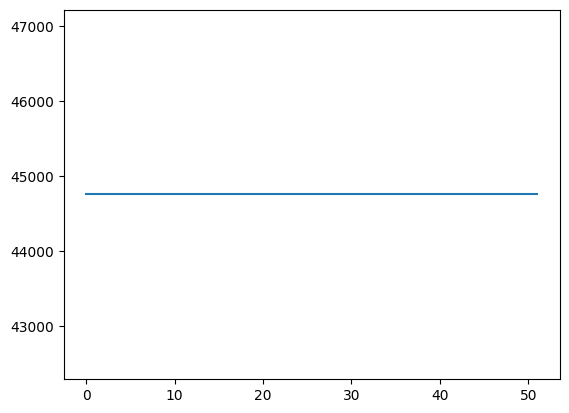

In [7]:
y_axis=[]
x_axis=[]
date=[]

for i in range(0,unit_odometer.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit_odometer.iloc[i,6][8:15]))
    x_axis.append(i)
    date.append(unit_odometer.iloc[i,7])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

#for i in range(133,171):
#    print(date[i],' -> ',x_axis[i],y_axis[i])

#plt.ylim(5230627,5240177)
#plt.xlim(133,171)
#plt.yticks(range(5230627,5240177,500))
#plt.xticks(range(133,171,5),rotation=90)
plt.plot(x_axis,y_axis)

In/outs

PS I0 I1 I2 I3 I4 I5 DI0
15 14 13 12 11 10 09 08 07 06 05 04 03 02 01 00 
          1  0  0  0  0  0  0  0  0  0  0  0  0
          1  0  0  0  0  0  0  0  0  0  0  0  0
          1  0  0  0  0  0  0  0  0  0  0  0  0

In [8]:
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
raw_data_df=pd.DataFrame()
#cad='0x252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])
    
for i in range(0,len(aux_cad)):    
    aux_value=aux_cad[i][64:68]
    if aux_value=='1000':
        aux_date.append(aux_cad[i][106:118])
        aux_raw_data.append(aux_cad[i])
        aux_input_number.append(2)
        print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

for i in range(0,len(aux_cad)):    
    aux_value=aux_cad[i][64:68]
    if aux_value=='2000':
        aux_date.append(aux_cad[i][106:118])
        aux_raw_data.append(aux_cad[i])
        aux_input_number.append(1)
        print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

raw_data_df['Date']=aux_date
raw_data_df['raw_data']=aux_raw_data
raw_data_df['Input']=aux_input_number

raw_data_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_to_jira.csv')

    

1000 0b1000000000000 260420212314 0x252514005908DE0869487060215778003C38402D000000594D0000000000001000000000000004FFFFFFFFFFFF44D50000AED51026042021231400E07E445A0D99C219C95D400000000003591172FFFFFF00001F0000FFFFFF
1000 0b1000000000000 260420212403 0x252514005908E00869487060215778003C38402D000000594E0000000000001000000000000000FFFFFFFFFFFF44D50000AED51026042021240300E07E445A0D99C219C95D400000000003591176FFFFFF00001F0000FFFFFF
1000 0b1000000000000 260420212404 0x252514005908E20869487060215778003C38402D00000059CE0000000000001000000000000001FFFFFFFFFFFF44D50000AED51026042021240400E07E445A0D99C219C95D400000000003591163FFFFFF00001F0000FFFFFF
1000 0b1000000000000 260420212713 0x252514005908E40869487060215778003C38402D000000564D0000000000001000000000000000FFFFFFFFFFFF44D50000AED51026042021271300E07E445A0D99C219C95D400000000003601174FFFFFF00001F0001FFFFFF
1000 0b1000000000000 260420212716 0x252514005908E60869487060215778003C38402D000000594E0000000000001000000000000000FFFFFFFFFFFF44D50000AED510